Був присутній на парі 09.04

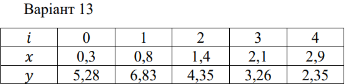

In [10]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
# Дані
x = np.array([0.3, 0.8, 1.4, 2.1, 2.9])
y = np.array([5.28, 6.83, 4.35, 3.26, 2.35])
n = len(x) - 1
h = np.diff(x)
a = y
b = np.zeros(n)
d = np.zeros(n)
c = np.zeros(n + 1) # Розширюємо на один елемент для останнього індексу
c[n]
alpha = np.zeros(n)
for i in range(1, n):
 alpha[i] = (3 / h[i]) * (a[i+1] - a[i]) - (3 / h[i-1]) * (a[i] - a[i-1])
l = np.ones(n + 1) # Розширюємо l на один елемент
mu = np.zeros(n)
z = np.zeros(n + 1) # Розширюємо на один елемент
# Пряма хода для знаходження l, mu, z
for i in range(1, n):
 l[i] = 2 * (x[i+1] - x[i-1]) - h[i-1] * mu[i-1]
 mu[i] = h[i] / l[i]
 z[i] = (alpha[i] - h[i-1] * z[i-1]) / l[i]
# Крайова умова: c[n] = 0
l[n] = 1
z[n] = 0
c[n] = 0
# Зворотний хід для знаходження c, b, d
for j in range(n-1, -1, -1):
 c[j] = z[j] - mu[j] * c[j+1]
 b[j] = (a[j+1] - a[j]) / h[j] - h[j] * (c[j+1] + 2 * c[j]) / 3
 d[j] = (c[j+1] - c[j]) / (3 * h[j])
# Виведення аналітичного вигляду кубічного сплайну для кожного відрізка
for i in range(n):
 print(f"Відрізок {i+1}:")
 print(f"S_{i}(x) = {a[i]} + {b[i].round(4)}(x - {x[i]}) + {c[i].round(4)}(x - {x[i]})^2 + {d[i].round(4)}(x - {x[i]})^3, xналежить [{x[i]}, {x[i+1]}]")

Відрізок 1:
S_0(x) = 5.28 + 5.011(x - 0.3) + 0.0(x - 0.3)^2 + -7.6439(x - 0.3)^3, xналежить [0.3, 0.8]
Відрізок 2:
S_1(x) = 6.83 + -0.7219(x - 0.8) + -11.4658(x - 0.8)^2 + 9.6335(x - 0.8)^3, xналежить [0.8, 1.4]
Відрізок 3:
S_2(x) = 4.35 + -4.0767(x - 1.4) + 5.8745(x - 1.4)^2 + -3.2503(x - 1.4)^3, xналежить [1.4, 2.1]
Відрізок 4:
S_3(x) = 3.26 + -0.6303(x - 2.1) + -0.9511(x - 2.1)^2 + 0.3963(x - 2.1)^3, xналежить [2.1, 2.9]


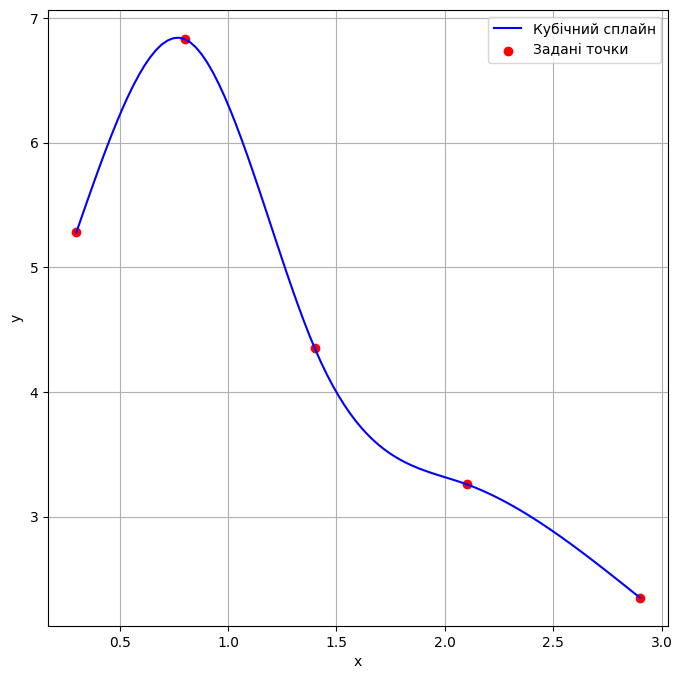

In [13]:
# Побудова графіка
x_values = np.linspace(np.min(x), np.max(x), 100) # Діапазон для побудови графіка
y_values = [ ]# Значення сплайна
# Обчислення значень сплайна для кожного відрізка
for i in range(n):
 mask = (x_values >= x[i]) & (x_values <= x[i + 1])
 x_interval = x_values[mask]
 y_interval = a[i] + b[i] * (x_interval - x[i]) + c[i] * (x_interval - x[i]) ** 2 + d[i] * (x_interval - x[i]) ** 3
 y_values.extend(y_interval)
# Побудова графіка
plt.figure(figsize=(8, 8))
plt.plot(x_values, y_values, label="Кубічний сплайн", color='b')
plt.scatter(x, y, label="Задані точки", color='r')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

Перевірка за допомогою методу CubicSpline

In [11]:
from scipy.interpolate import CubicSpline
# Вхідні дані
x = np.array([0.3, 0.8, 1.4, 2.1, 2.9])
y = np.array([5.28, 6.83, 4.35, 3.26, 2.35])
# Побудова кубічного сплайну
cs = CubicSpline(x, y)
# Виведення коефіцієнтів сплайну для кожного відрізка
for i in range(len(x)-1):
 coeffs = cs.c[:, i] # Коефіцієнти для i-го інтервалу
 spline = f'S_{i+1}(x) = {coeffs[0]:.4f}*(x - {x[i]})^3 + {coeffs[1]:.4f}*(x - {x[i]})^2 + {coeffs[2]:.4f}*(x - {x[i]}) + {coeffs[3]:.4f}'
 print(spline)

S_1(x) = 6.5230*(x - 0.3)^3 + -17.0126*(x - 0.3)^2 + 9.9756*(x - 0.3) + 5.2800
S_2(x) = 6.5230*(x - 0.8)^3 + -7.2281*(x - 0.8)^2 + -2.1448*(x - 0.8) + 6.8300
S_3(x) = -1.9244*(x - 1.4)^3 + 4.5134*(x - 1.4)^2 + -3.7736*(x - 1.4) + 4.3500
S_4(x) = -1.9244*(x - 2.1)^3 + 0.4722*(x - 2.1)^2 + -0.2837*(x - 2.1) + 3.2600


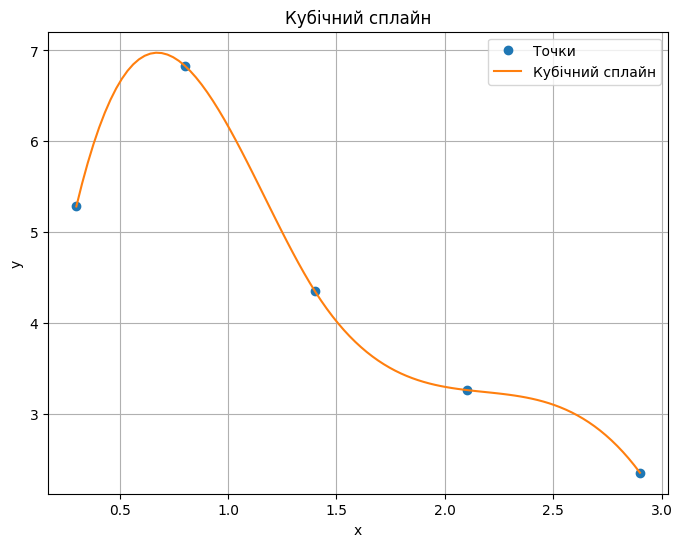

In [12]:
# Побудова кубічного сплайна
cs = CubicSpline(x, y)
# Генерація нових точок для гладкого графіку сплайна
x_new = np.linspace(np.min(x), np.max(x), 100)
y_new = cs(x_new)
# Побудова графіку
plt.figure(figsize=(8, 6))
plt.plot(x, y, 'o', label='Точки')
plt.plot(x_new, y_new, label='Кубічний сплайн')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Кубічний сплайн')
plt.legend()
plt.grid(True)
plt.show()